# Practice Task: AI for Last-Mile Route Optimization
## Course: AI for Logistics and Supply Chains

### Introduction
Last-mile delivery is the most expensive and complex part of the supply chain. In this task, you will explore how AI and optimization techniques can improve delivery efficiency. You will use a simulated dataset of delivery locations and develop a routing solution to minimize total distance traveled while respecting vehicle capacity and time window constraints.

### Task Objectives
1.  **Data Preparation**: Load and visualize the delivery locations.
2.  **Distance Calculation**: Compute a distance matrix between all locations.
3.  **Heuristic Implementation**: Develop a Nearest Neighbor heuristic for route generation.
4.  **Route Evaluation**: Analyze the performance of your routes based on total distance and time window compliance.
5.  **Route Visualization**: Map the optimized routes for the delivery fleet.

### Instructions
- Follow the steps outlined in each section.
- Write your Python code in the provided code cells.
- Answer the discussion questions in the markdown cells.
- Ensure the `delivery_locations.csv` file is in the same directory as this notebook.

### Step 1: Data Preparation

Load the delivery locations and visualize them on a scatter plot.

   DeliveryID   Latitude   Longitude  Demand  TimeWindowStart  TimeWindowEnd  \
0           0  34.052200 -118.243700       0                0            600   
1           1  34.039654 -118.196742       7              112            230   
2           2  34.097271 -118.216187       1              439            534   
3           3  34.075399 -118.199750       4               80            158   
4           4  34.062066 -118.204217       4              186            335   

   ServiceTime  
0            0  
1           15  
2           10  
3           15  
4           15  


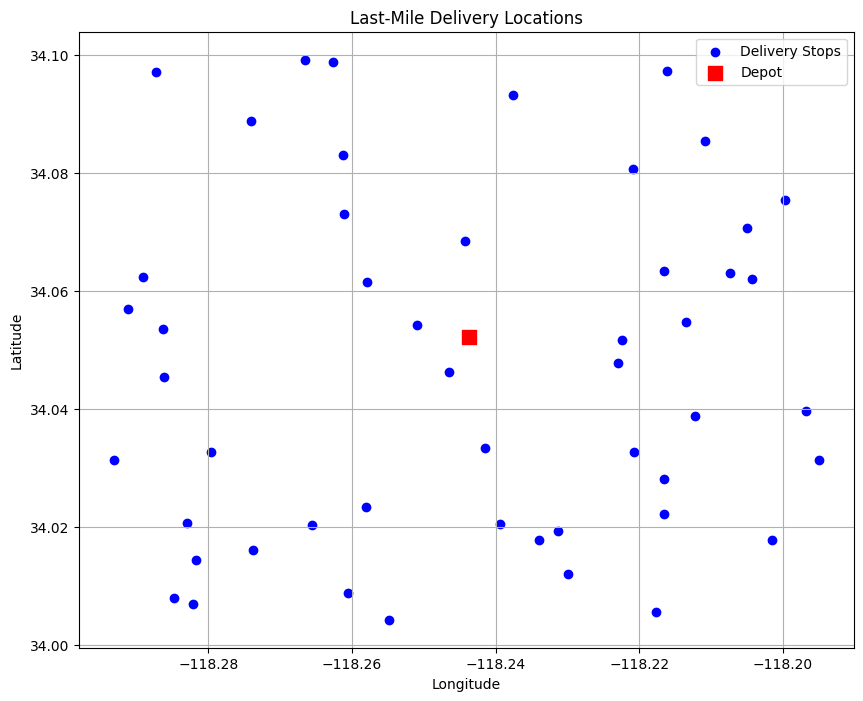

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import radians, cos, sin, asin, sqrt

# Load the dataset
df = pd.read_csv('delivery_locations.csv')

# Display the first few rows
print(df.head())

# Visualize delivery locations (Depot is DeliveryID 0)
plt.figure(figsize=(10, 8))
plt.scatter(df['Longitude'][1:], df['Latitude'][1:], color='blue', label='Delivery Stops')
plt.scatter(df['Longitude'][0], df['Latitude'][0], color='red', marker='s', s=100, label='Depot')
plt.title('Last-Mile Delivery Locations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True)
plt.show()

### Step 2: Distance Matrix Calculation

Calculate the distance matrix between all pairs of locations using the Haversine formula (or Euclidean distance as a simplification).

In [2]:
def haversine(lon1, lat1, lon2, lat2):
    # Convert decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    r = 6371 # Radius of earth in kilometers. Use 3956 for miles
    return c * r

num_locations = len(df)
dist_matrix = np.zeros((num_locations, num_locations))

for i in range(num_locations):
    for j in range(num_locations):
        dist_matrix[i, j] = haversine(df['Longitude'][i], df['Latitude'][i],
                                      df['Longitude'][j], df['Latitude'][j])

print("Distance Matrix (Sample 5x5):")
print(dist_matrix[:5, :5])

Distance Matrix (Sample 5x5):
[[0.         4.54586428 5.61594174 4.80048867 3.79909446]
 [4.54586428 0.         6.65241944 3.9843565  2.58550414]
 [5.61594174 6.65241944 0.         2.8646275  4.06693317]
 [4.80048867 3.9843565  2.8646275  0.         1.53866107]
 [3.79909446 2.58550414 4.06693317 1.53866107 0.        ]]


### Step 3: Heuristic Solver Implementation

Implement a basic Nearest Neighbor heuristic to create routes for a fleet of vehicles with a fixed capacity.

In [3]:
def nearest_neighbor_vrp(df, dist_matrix, vehicle_capacity):
    num_locations = len(df)
    visited = [False] * num_locations
    visited[0] = True # Depot is already visited (starting point)
    routes = []

    while sum(visited) < num_locations:
        current_route = [0] # Start at depot
        current_load = 0
        current_node = 0

        while True:
            nearest_node = -1
            min_dist = float('inf')

            for next_node in range(num_locations):
                if not visited[next_node] and df['Demand'][next_node] + current_load <= vehicle_capacity:
                    if dist_matrix[current_node, next_node] < min_dist:
                        min_dist = dist_matrix[current_node, next_node]
                        nearest_node = next_node

            if nearest_node == -1:
                break

            current_route.append(nearest_node)
            current_load += df['Demand'][nearest_node]
            visited[nearest_node] = True
            current_node = nearest_node

        current_route.append(0) # Return to depot
        routes.append(current_route)

    return routes

vehicle_capacity = 30 # Adjust capacity to change the number of routes
routes = nearest_neighbor_vrp(df, dist_matrix, vehicle_capacity)

print(f"Number of Routes Generated: {len(routes)}")
for i, route in enumerate(routes):
    print(f"Route {i+1}: {route}")

Number of Routes Generated: 10
Route 1: [0, 48, 40, 47, 16, 5, 45, 43, 0]
Route 2: [0, 29, 10, 36, 8, 12, 35, 34, 0]
Route 3: [0, 46, 26, 13, 2, 3, 4, 0]
Route 4: [0, 42, 25, 18, 21, 28, 0]
Route 5: [0, 37, 24, 1, 38, 0]
Route 6: [0, 14, 15, 22, 41, 50, 17, 23, 49, 0]
Route 7: [0, 31, 39, 44, 0]
Route 8: [0, 32, 27, 6, 33, 0]
Route 9: [0, 19, 9, 7, 30, 0]
Route 10: [0, 20, 11, 0]


### Step 4: Route Evaluation and Visualization

Calculate the total distance traveled and visualize the generated routes.

Total Distance for All Routes: 157.65 km


/tmp/ipykernel_13660/4271743264.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(routes))


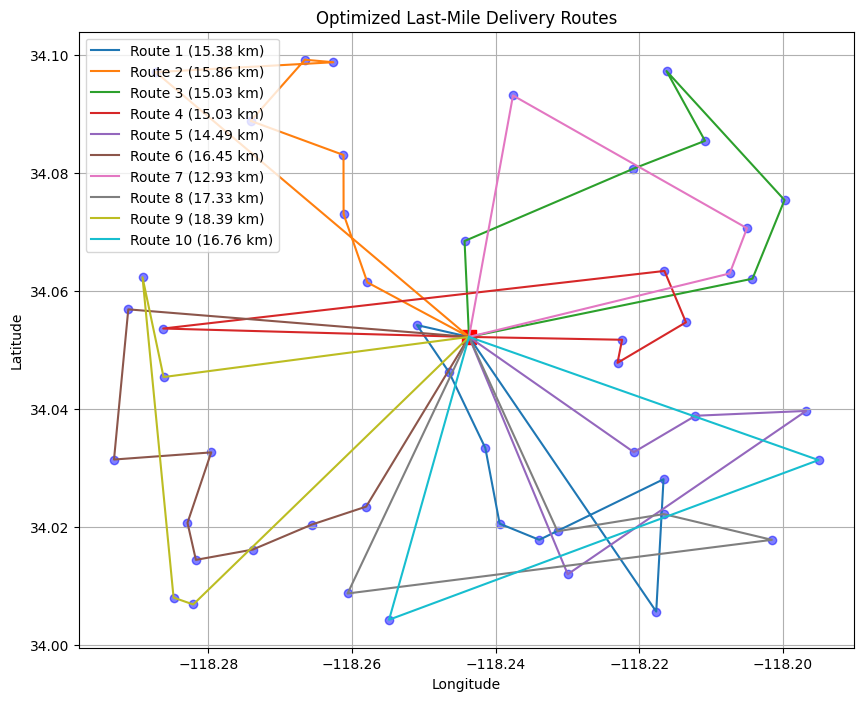

In [4]:
total_distance = 0
plt.figure(figsize=(10, 8))
plt.scatter(df['Longitude'][1:], df['Latitude'][1:], color='blue', alpha=0.5)
plt.scatter(df['Longitude'][0], df['Latitude'][0], color='red', marker='s', s=100)

colors = plt.cm.get_cmap('tab10', len(routes))

for i, route in enumerate(routes):
    route_dist = 0
    route_lats = []
    route_lons = []

    for j in range(len(route) - 1):
        u, v = route[j], route[j+1]
        route_dist += dist_matrix[u, v]
        route_lats.append(df['Latitude'][u])
        route_lons.append(df['Longitude'][u])

    route_lats.append(df['Latitude'][route[-1]])
    route_lons.append(df['Longitude'][route[-1]])

    total_distance += route_dist
    plt.plot(route_lons, route_lats, color=colors(i), label=f'Route {i+1} ({route_dist:.2f} km)')

print(f"Total Distance for All Routes: {total_distance:.2f} km")
plt.title('Optimized Last-Mile Delivery Routes')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True)
plt.show()

### Step 5: Discussion and Insights

Based on your results, answer the following questions:

1.  **Heuristic Limitations**: The Nearest Neighbor heuristic is a greedy algorithm. What are its main disadvantages for route optimization?
2.  **Constraint Trade-offs**: How does decreasing vehicle capacity affect the total distance and the number of vehicles required?
3.  **Real-world Complexity**: This model assumes constant travel speed and direct distances. How would real-time traffic data and road networks change the optimization process?
4.  **AI Integration**: How could more advanced AI techniques (e.g., Reinforcement Learning or Metaheuristics) be used to improve upon this basic solution?

### 1. Heuristic Limitations
The Nearest Neighbor algorithm is greedy, meaning it always chooses the closest next location.  
Its main disadvantage is that it does not guarantee the optimal route.  
It can get stuck in local optima and produce longer total distances compared to more advanced algorithms.

---

### 2. Constraint Trade-offs
When vehicle capacity decreases, more vehicles are required to complete all deliveries.  
This increases the total distance traveled because routes cannot be efficiently combined.  
As a result, delivery efficiency decreases and operational costs increase.

---

### 3. Real-world Complexity
This model assumes constant travel speed and direct distances, which is not realistic.  
In real life, traffic, road conditions, and delays affect travel time.  
Using real-time traffic data would allow dynamic route optimization and improve delivery accuracy.

---

### 4. AI Integration
Advanced AI techniques such as Reinforcement Learning or metaheuristics (e.g., Genetic Algorithms) can improve routing.  
These methods can explore more possible solutions and find better routes than simple heuristics.  
They can also adapt to dynamic environments and changing conditions.